In [1]:
# ELEC 6604 Assignment 1 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import copy

# ANN Training
import pandas as pd
import random
import time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam, SGD

In [3]:
# Part 1: Perceptron 12 data points linearly Separable
#-----------------------------------------------------
# Perceptron parameters
W12=-3
W13= 2
theta = -1
learnrate = 0.3

# training instances are defined
tmpp= np.array([
    [1.0000  ,  1.0000   ,  1.0000],
    [1.0000  ,  0.5000  ,   1.0000],
    [1.5000  ,  0.2000  ,   1.0000],
    [0.5000  ,  0.7500  ,   1.0000],
    [1.2000  ,  1.5000  ,   1.0000],
    [1.6000  ,  1.2000  ,   1.0000],
    [0.5000  ,  0.3000  ,   0.0000],
    [0.5000  ,  -0.7000 ,   0.0000],
    [0.0000  ,  0.2    ,    0.0000],
    [-0.7    ,  0.9000   ,  0.0000],
    [-0.6    ,  -0.5    ,   0.0000],
    [-0.5    ,  0.5     ,   0.0000]
   ])
print(tmpp.shape)

(12, 3)


In [4]:
X2=tmpp[:,0]
X3=tmpp[:,1]
desiredout=tmpp[:,2]
print('X2 = ', X2)
print('X3 = ', X3)
print('desiredout = ',desiredout)

X2 =  [ 1.   1.   1.5  0.5  1.2  1.6  0.5  0.5  0.  -0.7 -0.6 -0.5]
X3 =  [ 1.    0.5   0.2   0.75  1.5   1.2   0.3  -0.7   0.2   0.9  -0.5   0.5 ]
desiredout =  [1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0.]


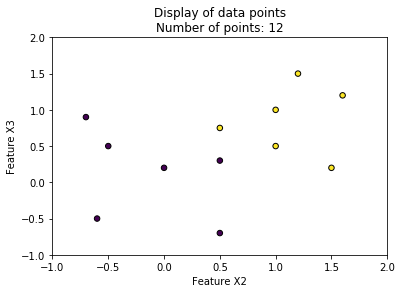

In [5]:
# plot
Num_datapoints = len(X2)
plt.scatter(X2, X3, c=desiredout, cmap='viridis', edgecolors='k', s=30)
plt.title(f'Display of data points\n'
              f'Number of points: {Num_datapoints}')
plt.xlabel('Feature X2')
plt.ylabel('Feature X3')
plt.xlim(-1, 2)  # xmin=-1, xmax=2
plt.ylim(-1, 2)  
plt.show()

In [6]:
# training of perceptrons
out = -1
for iteration in range(10):  # i=0,1,2,3,...,9
    totalerror=0
    for j in range(Num_datapoints):  # j=0,1,2,3,....
        tmpout=W12*X2[j]+W13*X3[j]+theta
        if (tmpout > 0):
            out = 1
        else:
            out = 0
        diff = desiredout[j] - out
        W12 = W12 + learnrate*diff*X2[j]; # error correction learning rule
        W13 = W13 + learnrate*diff*X3[j];
        theta = theta + learnrate*diff;
        totalerror = totalerror + np.abs(diff);
        #debug print(iteration, j, totalerror, W12, W13, theta)
        


In [7]:
# Create meshgrid for decision boundary visualization
xx, yy = np.meshgrid(np.linspace(-1, 2, 100),
                     np.linspace(-1, 2, 100))
print('xx.shape =  ', xx.shape)


xx.shape =   (100, 100)


In [8]:
# Get output for the grid points to plot decision boundaries
percept = copy.deepcopy(xx)

for ixx in range(100):  
    for iyy in range(100):  
        tmpout=W12*xx[ixx,iyy]+W13*yy[ixx,iyy]+theta
        if (tmpout > 0):
            percept[ixx,iyy] = 1
        else:
            percept[ixx,iyy] = 0

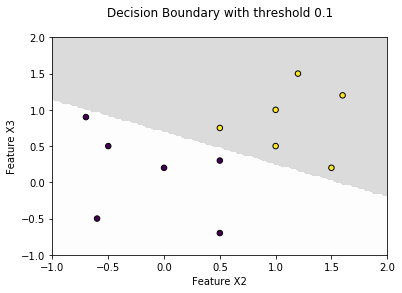

In [11]:
# Visualize the decision boundary
threshold_1 = 0.5

plt.contourf(xx, yy, percept, levels=[0, threshold_1, 1], alpha=0.3, cmap=plt.cm.Greys)
plt.scatter(X2, X3, c=desiredout, cmap='viridis', edgecolors='k', s=30)

plt.title(f'Decision Boundary with threshold {threshold_1}\n')
plt.xlabel('Feature X2')
plt.ylabel('Feature X3')

plt.show()

In [9]:
#
# Part 2: ANN 12 data points linearly Separable
#----------------------------------------------
# Keras is demonstrated. It is a high-level API for building and training ANN
# ANN model. The demo is for an ANN with two inputs, one output.
# One hidden layer

Number_hidden_units = 15

def baseline_model1():
    model = Sequential()
    model.add(Dense(Number_hidden_units, activation='relu', input_dim = 2))

    model.add(Dense(1, activation='sigmoid')) # Output layer for binary classification
    
    model.compile(optimizer=SGD(learning_rate = 0.3),loss='binary_crossentropy',
                  metrics=['accuracy'])
    
    return model

In [10]:
# training instances are defined
tmpp= np.array([
    [1.0000  ,  1.0000   ,  1.0000],
    [1.0000  ,  0.5000  ,   1.0000],
    [1.5000  ,  0.2000  ,   1.0000],
    [0.5000  ,  0.7500  ,   1.0000],
    [1.2000  ,  1.5000  ,   1.0000],
    [1.6000  ,  1.2000  ,   1.0000],
    [0.5000  ,  0.3000  ,   0.0000],
    [0.5000  ,  -0.7000 ,   0.0000],
    [0.0000  ,  0.2    ,    0.0000],
    [-0.7    ,  0.9000   ,  0.0000],
    [-0.6    ,  -0.5    ,   0.0000],
    [-0.5    ,  0.5     ,   0.0000]
   ])
train_x=tmpp[:,0:2]
train_y=tmpp[:,2]

train_y = train_y.reshape((len(train_y),1))

print(train_x.shape)
print(train_y.shape)

ANN_model = baseline_model1()
ANN_model.summary()

(12, 2)
(12, 1)
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 15)                45        
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 16        
Total params: 61
Trainable params: 61
Non-trainable params: 0
_________________________________________________________________


In [11]:
start_time = time.time()

history = ANN_model.fit(train_x, train_y, epochs=100, verbose = 0)
# Use verbose = 1 for details of training

end_time = time.time()
exe_time = end_time - start_time
print("Execution time: ", exe_time)

scores = ANN_model.evaluate(train_x,train_y,verbose = 0)
print("Training Accuracy = ", scores)

Execution time:  1.151207685470581
Training Accuracy =  [0.06724520027637482, 1.0]


In [12]:
xx, yy = np.meshgrid(np.linspace(-1, 2, 300),
                     np.linspace(-1, 2, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
print('grid.shape is ', grid.shape)

print('xx.shape is ', xx.shape)

grid.shape is  (90000, 2)
xx.shape is  (300, 300)


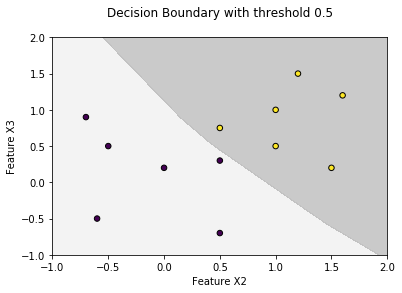

In [13]:
ANN_probs = ANN_model.predict(grid).reshape(xx.shape)

# Visualize the decision boundary
threshold_1 = 0.5

X2=tmpp[:,0]
X3=tmpp[:,1]
desiredout=tmpp[:,2]

plt.contourf(xx, yy, ANN_probs, levels=[0, threshold_1, 1], alpha=0.3, 
             cmap=plt.cm.Greys)
plt.scatter(X2, X3, c=desiredout, cmap='viridis', edgecolors='k', s=30)

plt.title(f'Decision Boundary with threshold {threshold_1}\n')
plt.xlabel('Feature X2')
plt.ylabel('Feature X3')

plt.show()

In [12]:
# Part 3: ANN with data points not linearly separable
#----------------------------------------------------
# One hidden layer
# ANN demo: 20 training instances are defined
# These points are not linearly separable
#
tmpp= np.array([
    [1.0000  ,  1.0000   ,  1.0000],
    [1.1000  ,  0.6000  ,   1.0000],
    [1.5000  ,  0.2000  ,   1.0000],
    [-0.5000  , 0.7500  ,   1.0000],
    [-0.5000  , 1.5000  ,   1.0000],
    [-0.1000  , 0.9000  ,   1.0000],
    [ 0.6000  , 1.2    ,    1.0000],
    [1.5000   , 1.5     ,   1.0000],
    [1.8000  ,  1.0000   ,  1.0000],
    [1.8000  ,  0.2000  ,   1.0000],
    [-0.8000  , -0.1000  ,  0.0000],
    [-0.4000  , 0.2000  ,   0.0000],
    [-0.6000  , 0.1500  ,   0.0000],
    [-0.2000  , -0.4000 ,   0.0000],
    [1.2000  ,  0.1    ,    0.0000],
    [1.5    ,  -0.6     ,   0.0000],
    [0.5000  ,  0.7500  ,   0.0000],
    [0.5000  ,  0.3000 ,    0.0000],
    [0.5000  ,  -0.7000 ,   0.0000],
    [0.0000    , 0.2000 ,   0.0000],
   ])
print(tmpp.shape)

(20, 3)


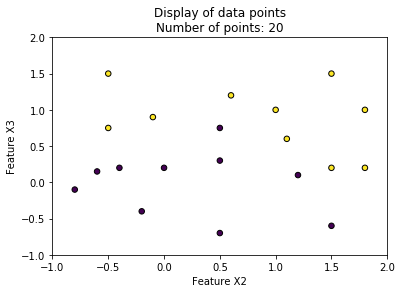

In [13]:
X2=tmpp[:,0]
X3=tmpp[:,1]
desiredout=tmpp[:,2]

Num_datapoints = len(X2)
plt.scatter(X2, X3, c=desiredout, cmap='viridis', edgecolors='k', s=30)
plt.title(f'Display of data points\n'
              f'Number of points: {Num_datapoints}')
plt.xlabel('Feature X2')
plt.ylabel('Feature X3')
plt.xlim(-1, 2)  # xmin=-1, xmax=2
plt.ylim(-1, 2)  
plt.show()

In [14]:
# ANN model of the two inputs
# One hidden layer

Number_hidden_units = 20

def baseline_model1():
    model = Sequential()
    model.add(Dense(Number_hidden_units, activation='relu', input_dim = 2))
    model.add(Dense(1, activation='sigmoid')) # Output layer for binary classification
    
    model.compile(optimizer=SGD(learning_rate = 0.3),loss='binary_crossentropy',
                  metrics=['accuracy'])
    
    return model

In [15]:
train_x=tmpp[:,0:2]
train_y=tmpp[:,2]
train_y = train_y.reshape((20,1))
print(train_x.shape)
print(train_y.shape)

ANN_model = baseline_model1()
ANN_model.summary()

(20, 2)
(20, 1)
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 20)                60        
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 21        
Total params: 81
Trainable params: 81
Non-trainable params: 0
_________________________________________________________________


In [16]:

start_time = time.time()

history = ANN_model.fit(train_x, train_y, epochs=400, verbose = 0)
# Use verbose = 1 for details of training

end_time = time.time()
exe_time = end_time - start_time
print("Execution time: ", exe_time)

scores = ANN_model.evaluate(train_x,train_y,verbose = 2)
print("Training Accuracy = ", scores)


Execution time:  1.519629716873169
1/1 - 0s - loss: 0.0482 - accuracy: 1.0000
Training Accuracy =  [0.04817577451467514, 1.0]


In [17]:
# Make predictions and evaluate the training accuracy
y_pred = ANN_model.predict(train_x)
print(y_pred)
print(train_y)

[[9.8609668e-01]
 [8.9053249e-01]
 [8.5845459e-01]
 [9.3952715e-01]
 [9.9997425e-01]
 [9.4279099e-01]
 [9.7942150e-01]
 [9.9998963e-01]
 [9.9995625e-01]
 [9.8394281e-01]
 [2.3987591e-03]
 [8.3089471e-03]
 [1.1722326e-02]
 [1.9509551e-05]
 [1.8479085e-01]
 [9.7569525e-03]
 [2.4161926e-01]
 [7.3133111e-03]
 [5.9245854e-06]
 [2.0180643e-03]]
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]


In [18]:
xx, yy = np.meshgrid(np.linspace(-1, 2, 300),
                     np.linspace(-1, 2, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
print(grid.shape)


(90000, 2)


In [19]:
ANN_probs = ANN_model.predict(grid).reshape(xx.shape)

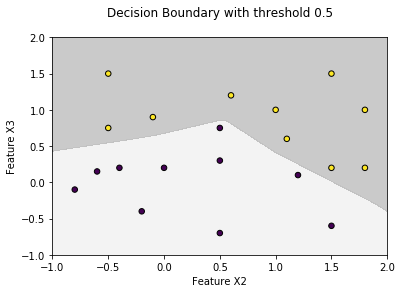

In [20]:
# Visualize the decision boundary
threshold_1 = 0.5

plt.contourf(xx, yy, ANN_probs, levels=[0, threshold_1, 1], alpha=0.3, 
             cmap=plt.cm.Greys)
plt.scatter(X2, X3, c=desiredout, cmap='viridis', edgecolors='k', s=30)

plt.title(f'Decision Boundary with threshold {threshold_1}\n')
plt.xlabel('Feature X2')
plt.ylabel('Feature X3')

plt.show()

In [21]:
# Part 4: ANN with data points not linearly separable
#----------------------------------------------------
# ANN model of the two inputs, one output
# Two hidden layers

Number_hidden1_units = 15
Number_hidden2_units = 10

def baseline_model2():
    model = Sequential()
    model.add(Dense(Number_hidden1_units, activation='relu', input_dim = 2))
    model.add(Dense(Number_hidden2_units, activation='relu'))
    model.add(Dense(1, activation='sigmoid')) # Output layer for binary classification
    
    model.compile(optimizer=SGD(learning_rate = 0.15),loss='binary_crossentropy',
                  metrics=['accuracy'])
    
    return model

ANN_model = baseline_model2()
ANN_model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_2 (Dense)              (None, 15)                45        
_________________________________________________________________
dense_3 (Dense)              (None, 10)                160       
_________________________________________________________________
dense_4 (Dense)              (None, 1)                 11        
Total params: 216
Trainable params: 216
Non-trainable params: 0
_________________________________________________________________


In [22]:
# Start training

history = ANN_model.fit(train_x, train_y, epochs=300, verbose = 2)

ANN_probs = ANN_model.predict(grid).reshape(xx.shape)


Epoch 1/300
1/1 - 0s - loss: 0.5904 - accuracy: 0.5500
Epoch 2/300
1/1 - 0s - loss: 0.5789 - accuracy: 0.5500
Epoch 3/300
1/1 - 0s - loss: 0.5684 - accuracy: 0.5500
Epoch 4/300
1/1 - 0s - loss: 0.5586 - accuracy: 0.5500
Epoch 5/300
1/1 - 0s - loss: 0.5493 - accuracy: 0.6000
Epoch 6/300
1/1 - 0s - loss: 0.5412 - accuracy: 0.6500
Epoch 7/300
1/1 - 0s - loss: 0.5336 - accuracy: 0.8000
Epoch 8/300
1/1 - 0s - loss: 0.5262 - accuracy: 0.8000
Epoch 9/300
1/1 - 0s - loss: 0.5192 - accuracy: 0.8000
Epoch 10/300
1/1 - 0s - loss: 0.5124 - accuracy: 0.8000
Epoch 11/300
1/1 - 0s - loss: 0.5058 - accuracy: 0.8000
Epoch 12/300
1/1 - 0s - loss: 0.4993 - accuracy: 0.8000
Epoch 13/300
1/1 - 0s - loss: 0.4929 - accuracy: 0.8000
Epoch 14/300
1/1 - 0s - loss: 0.4866 - accuracy: 0.8500
Epoch 15/300
1/1 - 0s - loss: 0.4805 - accuracy: 0.8500
Epoch 16/300
1/1 - 0s - loss: 0.4745 - accuracy: 0.8500
Epoch 17/300
1/1 - 0s - loss: 0.4686 - accuracy: 0.8500
Epoch 18/300
1/1 - 0s - loss: 0.4628 - accuracy: 0.8500
E

Epoch 147/300
1/1 - 0s - loss: 0.1564 - accuracy: 0.9500
Epoch 148/300
1/1 - 0s - loss: 0.1549 - accuracy: 0.9500
Epoch 149/300
1/1 - 0s - loss: 0.1539 - accuracy: 0.9500
Epoch 150/300
1/1 - 0s - loss: 0.1530 - accuracy: 0.9500
Epoch 151/300
1/1 - 0s - loss: 0.1514 - accuracy: 0.9500
Epoch 152/300
1/1 - 0s - loss: 0.1508 - accuracy: 0.9500
Epoch 153/300
1/1 - 0s - loss: 0.1495 - accuracy: 0.9500
Epoch 154/300
1/1 - 0s - loss: 0.1483 - accuracy: 0.9500
Epoch 155/300
1/1 - 0s - loss: 0.1477 - accuracy: 0.9500
Epoch 156/300
1/1 - 0s - loss: 0.1461 - accuracy: 0.9500
Epoch 157/300
1/1 - 0s - loss: 0.1453 - accuracy: 0.9500
Epoch 158/300
1/1 - 0s - loss: 0.1443 - accuracy: 0.9500
Epoch 159/300
1/1 - 0s - loss: 0.1430 - accuracy: 0.9500
Epoch 160/300
1/1 - 0s - loss: 0.1423 - accuracy: 0.9500
Epoch 161/300
1/1 - 0s - loss: 0.1410 - accuracy: 0.9500
Epoch 162/300
1/1 - 0s - loss: 0.1400 - accuracy: 0.9500
Epoch 163/300
1/1 - 0s - loss: 0.1394 - accuracy: 0.9500
Epoch 164/300
1/1 - 0s - loss: 

Epoch 291/300
1/1 - 0s - loss: 0.0531 - accuracy: 1.0000
Epoch 292/300
1/1 - 0s - loss: 0.0527 - accuracy: 1.0000
Epoch 293/300
1/1 - 0s - loss: 0.0525 - accuracy: 1.0000
Epoch 294/300
1/1 - 0s - loss: 0.0522 - accuracy: 1.0000
Epoch 295/300
1/1 - 0s - loss: 0.0517 - accuracy: 1.0000
Epoch 296/300
1/1 - 0s - loss: 0.0513 - accuracy: 1.0000
Epoch 297/300
1/1 - 0s - loss: 0.0512 - accuracy: 1.0000
Epoch 298/300
1/1 - 0s - loss: 0.0507 - accuracy: 1.0000
Epoch 299/300
1/1 - 0s - loss: 0.0503 - accuracy: 1.0000
Epoch 300/300
1/1 - 0s - loss: 0.0502 - accuracy: 1.0000


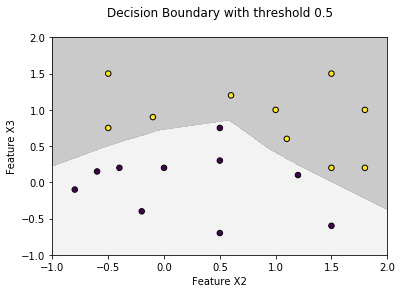

In [23]:
# Visualize the decision boundary
threshold_1 = 0.5

plt.contourf(xx, yy, ANN_probs, levels=[0, threshold_1, 1], alpha=0.3, 
             cmap=plt.cm.Greys)
plt.scatter(X2, X3, c=desiredout, cmap='viridis', edgecolors='k', s=30)

plt.title(f'Decision Boundary with threshold {threshold_1}\n')
plt.xlabel('Feature X2')
plt.ylabel('Feature X3')

plt.show()

In [24]:
# Part 5: ANN with data points not linearly separable
#----------------------------------------------------
# The MLPClassifier is a framework in the sklearn.neural_network module
# of the Scikit-learn library. It implements MLP for supervised learning tasks,
# specifically for classification problems.
#
# ANN model of the two inputs, one output
# Three hidden layers is used.

In [35]:
# Another ANN
# Define the hyperparameters for the neural network
hidden_layer_depth = 3  # Number of hidden layers
hidden_layer_width = 20  # Number of neurons per hidden layer

# Create a tuple representing the hidden layer sizes
hidden_layer_sizes = (hidden_layer_width,) * hidden_layer_depth

# Train a neural network on the training dataset
mlp = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, 
                    activation='relu',  # activation function for hidden layers
                    solver='sgd',  # optimization algorithm
                    max_iter=2000)
mlp.fit(train_x, train_y)

c:\users\gpang\appdata\local\programs\python\python36\lib\site-packages\sklearn\neural_network\multilayer_perceptron.py:916: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MLPClassifier(activation='relu', alpha=0.0001, batch_size='auto', beta_1=0.9,
       beta_2=0.999, early_stopping=False, epsilon=1e-08,
       hidden_layer_sizes=(20, 20, 20), learning_rate='constant',
       learning_rate_init=0.001, max_iter=2000, momentum=0.9,
       n_iter_no_change=10, nesterovs_momentum=True, power_t=0.5,
       random_state=None, shuffle=True, solver='sgd', tol=0.0001,
       validation_fraction=0.1, verbose=False, warm_start=False)

In [36]:
print(train_x.shape)
print(train_y.shape)
print(xx.shape)
ANN_probs = mlp.predict(grid).reshape(xx.shape)

(20, 2)
(20, 1)
(300, 300)


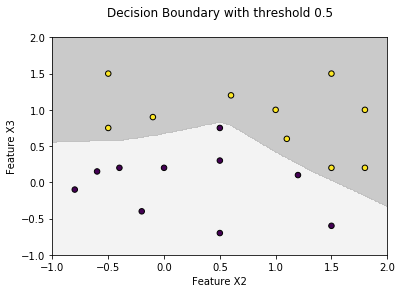

In [37]:
# Visualize the decision boundary
threshold_1 = 0.5

plt.contourf(xx, yy, ANN_probs, levels=[0, threshold_1, 1], alpha=0.3, 
             cmap=plt.cm.Greys)
plt.scatter(X2, X3, c=desiredout, cmap='viridis', edgecolors='k', s=30)

plt.title(f'Decision Boundary with threshold {threshold_1}\n')
plt.xlabel('Feature X2')
plt.ylabel('Feature X3')

plt.show()

In [141]:
# Make predictions and evaluate the training accuracy
y_pred = mlp.predict(train_x)
accuracy = accuracy_score(train_y, y_pred)
print(f'Test Accuracy: {accuracy * 100:.2f}%')

Test Accuracy: 100.00%


In [157]:
# Part 6: ANN with many data points not linearly separable
#----------------------------------------------------
# The MLPClassifier is used again in this example.

In [166]:
# Create a simple dataset
Num_datapoints = 300
X, y = make_moons(n_samples=Num_datapoints, noise=0.1, random_state=42)

In [167]:
print('X.shape: ', X.shape)
print('y.shape: ', y.shape)
print('min 1st column= ',np.min(X[:,0]), 'max 1st column= ', np.max(X[:,0])  )
print('min 2nd column= ',np.min(X[:,1]), 'max 2nd column= ', np.max(X[:,1])  )
print(X[0:3,:])
print(y)

X.shape:  (300, 2)
y.shape:  (300,)
min 1st column=  -1.2272758742530834 max 1st column=  2.2703863872199213
min 2nd column=  -0.6728418566502035 max 2nd column=  1.239950896359412
[[ 0.68298822 -0.34520334]
 [ 2.04099043 -0.13161467]
 [-0.13975154  0.4543905 ]]
[1 1 1 0 1 1 1 0 0 1 1 0 1 0 1 1 1 1 0 1 0 0 1 1 0 0 1 1 1 1 0 1 0 0 1 0 0
 0 0 0 0 0 1 0 0 0 1 1 0 1 1 0 1 0 1 1 0 0 1 0 1 0 0 1 1 0 0 1 0 1 0 0 1 1
 0 1 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1 0 1 0 0 1 1 1 0 0 1 0 0
 1 0 1 1 0 0 1 1 1 0 1 1 1 0 1 0 0 1 1 0 0 1 0 1 1 1 1 1 0 0 0 1 0 1 1 0 0
 0 0 1 0 1 1 1 1 1 0 1 0 1 1 0 0 0 0 1 1 1 0 0 1 1 0 0 1 0 0 1 0 1 0 1 1 0
 1 1 1 0 0 0 1 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 0 0 0 1 0 0 1 0 0 1 1 0 0 1
 1 1 0 1 0 0 1 1 0 1 1 1 1 0 0 0 1 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 0 0 0 0 1
 0 0 0 1 0 0 1 1 0 1 1 0 0 1 1 1 1 1 0 0 1 1 0 1 1 1 1 0 0 1 0 0 1 0 1 0 1
 0 0 1 0]


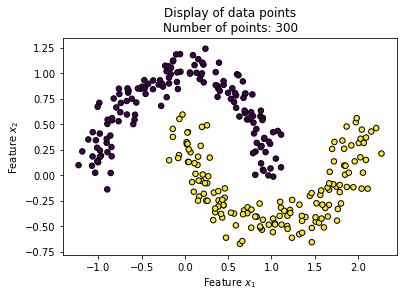

In [197]:
# Plotting of the dataset # cmap=plt.cm.Greys

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k', s=30)
plt.title(f'Display of data points\n'
              f'Number of points: {Num_datapoints}')
plt.xlabel('Feature $x_1$')
plt.ylabel('Feature $x_2$')
plt.show()

In [198]:

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (important in machine learning)
#scaler = StandardScaler()
#X_train = scaler.fit_transform(X_train)
#X_test = scaler.transform(X_test)

In [199]:
# Define the hyperparameters for the neural network
hidden_layer_depth = 3  # Number of hidden layers
hidden_layer_width = 15  # Number of neurons per hidden layer

# Create a tuple representing the hidden layer sizes
hidden_layer_sizes = (hidden_layer_width,) * hidden_layer_depth

# Train a neural network on the training dataset
mlp = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, 
                    activation='relu',  # activation function for hidden layers
                    solver='sgd',  # optimization algorithm
                    max_iter=3000)
mlp.fit(X_train, y_train)

MLPClassifier(activation='relu', alpha=0.0001, batch_size='auto', beta_1=0.9,
       beta_2=0.999, early_stopping=False, epsilon=1e-08,
       hidden_layer_sizes=(15, 15, 15), learning_rate='constant',
       learning_rate_init=0.001, max_iter=3000, momentum=0.9,
       n_iter_no_change=10, nesterovs_momentum=True, power_t=0.5,
       random_state=None, shuffle=True, solver='sgd', tol=0.0001,
       validation_fraction=0.1, verbose=False, warm_start=False)

In [200]:
# Make predictions and evaluate the testset accuracy
y_pred = mlp.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {accuracy * 100:.2f}%')

Test Accuracy: 100.00%


In [201]:
# Create meshgrid for decision boundary visualization
x_min, x_max = X_test[:, 0].min() - 0.5, X_test[:, 0].max() + 0.5
y_min, y_max = X_test[:, 1].min() - 0.5, X_test[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
print(grid.shape)

(90000, 2)


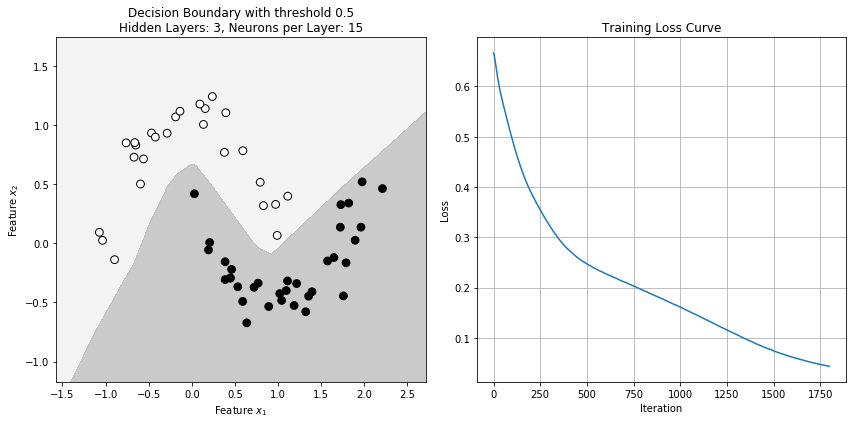

In [202]:
# Get probabilities for the grid points to plot decision boundaries
# Need to reshape to the same dimension as the xx
probs = mlp.predict_proba(grid)[:, 1].reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Visualize the decision boundary
threshold_1 = 0.5
ax1 = axes[0]
ax1.contourf(xx, yy, probs, levels=[0, threshold_1, 1], alpha=0.3, cmap=plt.cm.Greys)
ax1.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.Greys, edgecolors='k', s=60)
ax1.set_title(f'Decision Boundary with threshold {threshold_1}\n'
              f'Hidden Layers: {hidden_layer_depth}, Neurons per Layer: {hidden_layer_width}')
ax1.set_xlabel('Feature $x_1$')
ax1.set_ylabel('Feature $x_2$')


# Plot the training loss curve
ax2 = axes[1]
ax2.plot(mlp.loss_curve_)
ax2.set_title('Training Loss Curve')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Loss')
ax2.grid(True)

# Adjust layout for better visualization
plt.tight_layout()
plt.show()

In [203]:
print(hidden_layer_sizes)

(15, 15, 15)


In [212]:
# Part 7: ANN with 300 data points using Keras.
#----------------------------------------------
# ANN model of the two inputs, one output
# Two hidden layers

Number_hidden1_units = 15
Number_hidden2_units = 10

def baseline_model2():
    model = Sequential()
    model.add(Dense(Number_hidden1_units, activation='relu', input_dim = 2))
    model.add(Dense(Number_hidden2_units, activation='relu'))
    model.add(Dense(1, activation='sigmoid')) # Output layer for binary classification
    
    model.compile(optimizer=SGD(learning_rate = 0.15),loss='binary_crossentropy',
                  metrics=['accuracy'])
    
    return model

ANN_model = baseline_model2()
ANN_model.summary()

Model: "sequential_18"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_42 (Dense)             (None, 15)                45        
_________________________________________________________________
dense_43 (Dense)             (None, 10)                160       
_________________________________________________________________
dense_44 (Dense)             (None, 1)                 11        
Total params: 216
Trainable params: 216
Non-trainable params: 0
_________________________________________________________________


In [219]:
y_train = y_train.reshape((240,1))
print(X_train.shape)
print(y_train.shape)
print(y_test.shape)

(240, 2)
(240, 1)
(60,)


In [214]:
# Start training

history = ANN_model.fit(X_train, y_train, epochs=300, verbose = 0)

ANN_probs = ANN_model.predict(grid).reshape(xx.shape)

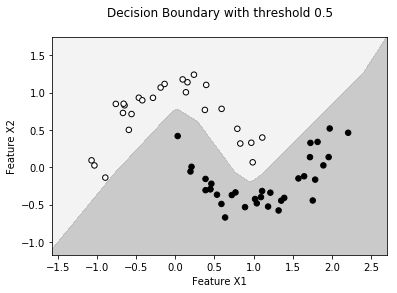

In [222]:
# Visualize the decision boundary
threshold_1 = 0.5

plt.contourf(xx, yy, ANN_probs, levels=[0, threshold_1, 1], alpha=0.3, 
             cmap=plt.cm.Greys)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.Greys, 
            edgecolors='k', s=30)

plt.title(f'Decision Boundary with threshold {threshold_1}\n')
plt.xlabel('Feature X1')
plt.ylabel('Feature X2')

plt.show()

In [4]:
# Demo of grid
x=np.linspace(0,1,3)
y=np.linspace(0,1,4)
xx, yy = np.meshgrid(x,y)
print('xx.shape = ', xx.shape, 'xx = ', xx)
print('yy.shape = ', yy.shape, 'yy = ' , yy)
kxx=xx.ravel()
print('kxx = ',kxx)
kyy=yy.ravel()
print('kyy = ',kyy)
grid = np.c_[xx.ravel(), yy.ravel()]
print('grid-shape ',  grid.shape)
print('grid = ', grid)

xx.shape =  (4, 3) xx =  [[0.  0.5 1. ]
 [0.  0.5 1. ]
 [0.  0.5 1. ]
 [0.  0.5 1. ]]
yy.shape =  (4, 3) yy =  [[0.         0.         0.        ]
 [0.33333333 0.33333333 0.33333333]
 [0.66666667 0.66666667 0.66666667]
 [1.         1.         1.        ]]
kxx =  [0.  0.5 1.  0.  0.5 1.  0.  0.5 1.  0.  0.5 1. ]
kyy =  [0.         0.         0.         0.33333333 0.33333333 0.33333333
 0.66666667 0.66666667 0.66666667 1.         1.         1.        ]
grid-shape  (12, 2)
grid =  [[0.         0.        ]
 [0.5        0.        ]
 [1.         0.        ]
 [0.         0.33333333]
 [0.5        0.33333333]
 [1.         0.33333333]
 [0.         0.66666667]
 [0.5        0.66666667]
 [1.         0.66666667]
 [0.         1.        ]
 [0.5        1.        ]
 [1.         1.        ]]


zz.shape =  (4, 3)


Text(0, 0.5, 'Feature $x_2$')

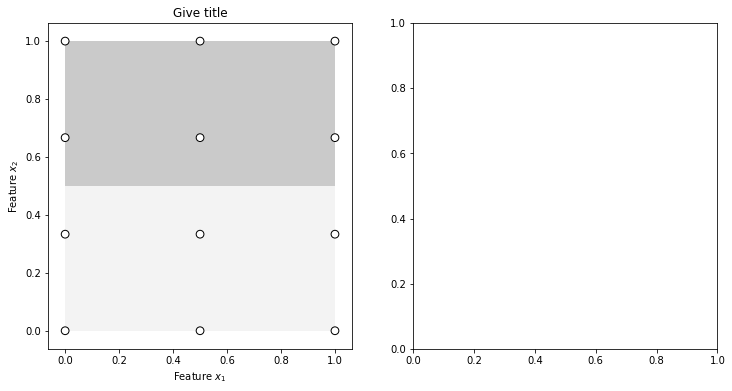

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
zz= np.array([
    [0, 0, 0],
    [0, 0, 0],
    [1, 1, 1],
    [1, 1, 1],
   ])
print('zz.shape = ',zz.shape)
# Visualize the decision boundary
ax1 = axes[0]
ax1.contourf(xx, yy, zz, levels=[0, 0.5, 1], alpha=0.3, cmap=plt.cm.Greys)
ax1.scatter(grid[:, 0], grid[:, 1], c=[1,1,1,1,1,1,1,1,1,1,1,1], cmap=plt.cm.Greys, 
            edgecolors='k', s=60)
ax1.set_title('Give title')
ax1.set_xlabel('Feature $x_1$')
ax1.set_ylabel('Feature $x_2$')